In [ ]:
在这个数据集中，活跃用户的男女比例本身就约为 7:3。男性用户基数极大，所以他们买任何东西（哪怕是连衣裙）的总人数都自然压过女性。
连衣裙的性别分布与全站大盘一致，无明显性别属性；而女衬衫、毛衣是吸引女性用户的有效品类；短裤、连帽衫则呈现明显的男性化倾向。”
验证目标人群匹配度：

如果本次大促主推“男性用品”，这张图说明你的流量人群是精准的（男性占7成）。

如果本次主推“女性连衣裙”，这张图就暴露出巨大的流量错配——你需要在分析中写：“由于活动流量以男性为主，导致连衣裙类目男性购买占比偏高，建议后续针对女性用户做定向拉新。”

如果非要画图，换一种画法（强烈推荐）：

不要再画“男女对比图”（因为对比没意义）。

改为画“女性购买人数TOP10品类”柱状图（只看女性列的数据），这样能直观看出女性用户最喜欢买什么（珠宝264人、女衬衫171人、毛衣164人）。

或者画“女性偏好指数”柱状图（即上面我算的女/男比值），找出哪些品类最能吸引女性（女衬衫、毛衣）。

① 分块读取 UserBehavior--1.csv ...
大促有效行为总行数：661401

② 读取 user_face.csv ...

③ 读取 ub_labels.csv ...

④ 读取 item_gender_ratio.csv ...

⑤ 计算 RFM 指标，并处理消费极端异常值 ...
M金额异常截断上限：795.80 元，超上限订单统一修正
总独立用户：10736，有购买用户：5677

===== RFM 中位数（已剔除极端消费）=====
R_days 中位数：4.85 天
F_buy_count 中位数：1 次
M_total_money中位数：22.80 元

⑥ 基于中位数进行用户分层 ...

===== 中位数分层统计（含平均消费）=====
     用户分层  用户数  占比%  平均消费(元)
   沉睡流失客户 5368 50.0     9.58
  高价值核心客户 2944 27.4   386.80
     潜力客户 2149 20.0   138.98
新客户（浏览浅客）  275  2.6    11.46

======== 各分层用户运营建议 ========

1. 高价值核心客户
人群特征：近期活跃、下单频次高、消费金额高于均值
运营策略：
- 专属会员权益、大额满减券、生日福利、新品优先购
- 一对一客服维护，定期推送高端品类
- 限制大额优惠券外流，提高留存，防止竞品分流

2. 潜力客户
人群特征：近期活跃，但下单次数/客单仅一项达标
运营策略：
- 发放品类满减券、组合套餐优惠，提升客单价/复购频次
- 加购未下单人群推送限时降价、运费券，提升加购转下单转化

3. 新客户（浏览浅客）
人群特征：仅浏览无成交，近期有曝光行为
运营策略：
- 新人首单立减、包邮券，降低首次下单门槛
- 推送爆款低价商品，引导完成首单转化
- 首页弹窗引导加购收藏，培育消费习惯

4. 沉睡流失客户
人群特征：超过中位数间隔无任何下单行为
运营策略：
- 沉睡3-7天：小额唤醒优惠券、专属秒杀推送
- 沉睡超7天：短信/站内信召回，大额限时券刺激回流
- 长期无互动减少推送频次，降低营销成本


运营策略已保存至：分层运营策略.csv

⑦ 关联用户职业画像 ...

⑧ 关联系统标签 ...

⑨ 计算浏览→

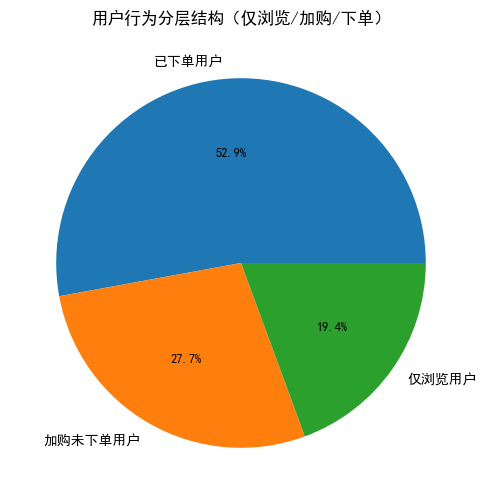

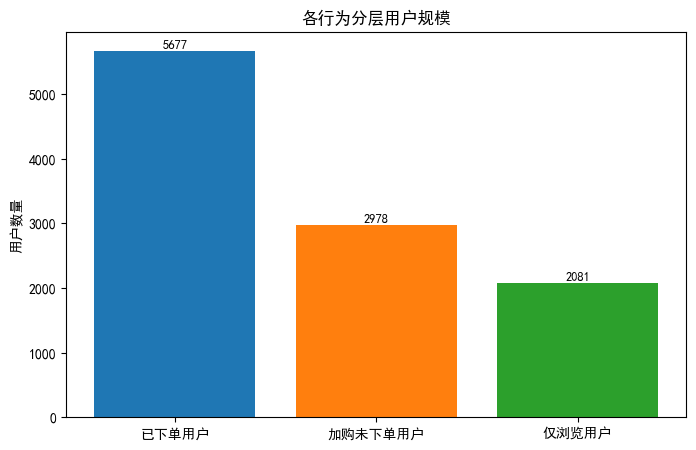


⑪ 导出结果文件 ...
✅ 所有 CSV 文件已导出。

⑫ 生成可视化图表 ...


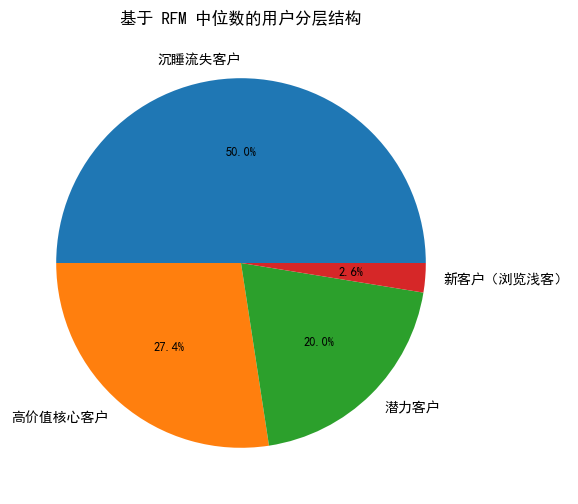

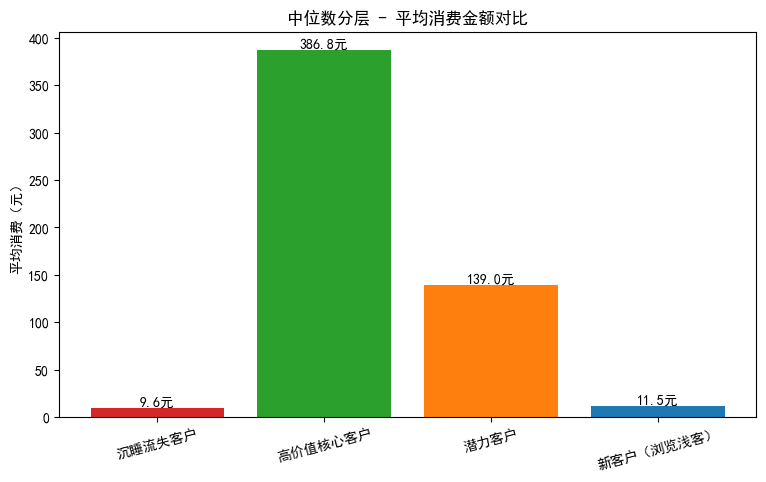

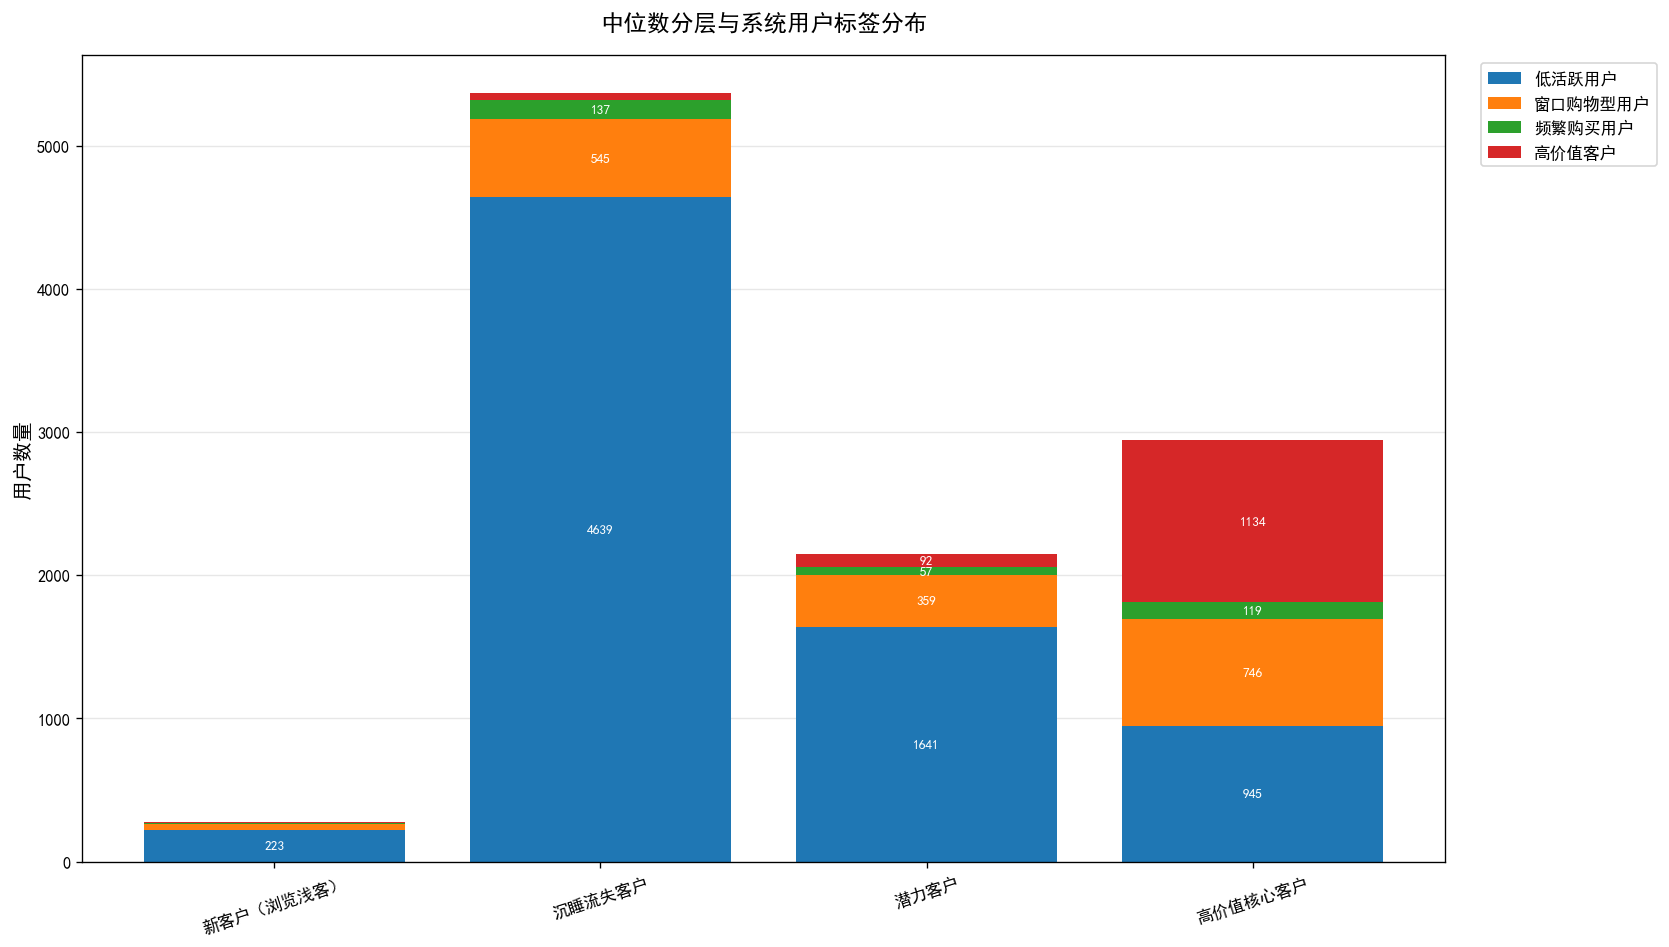

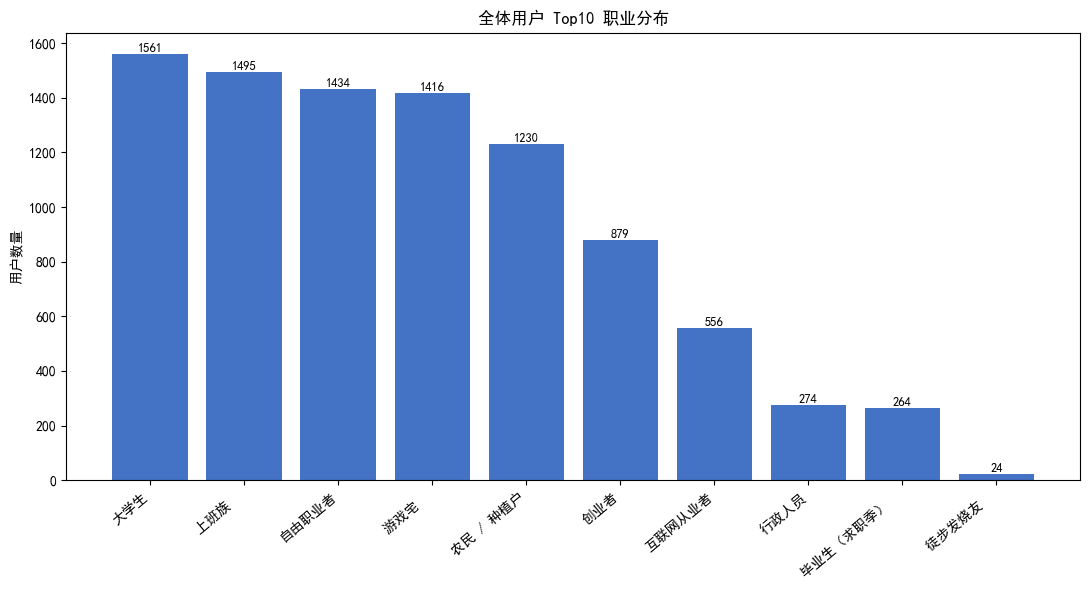

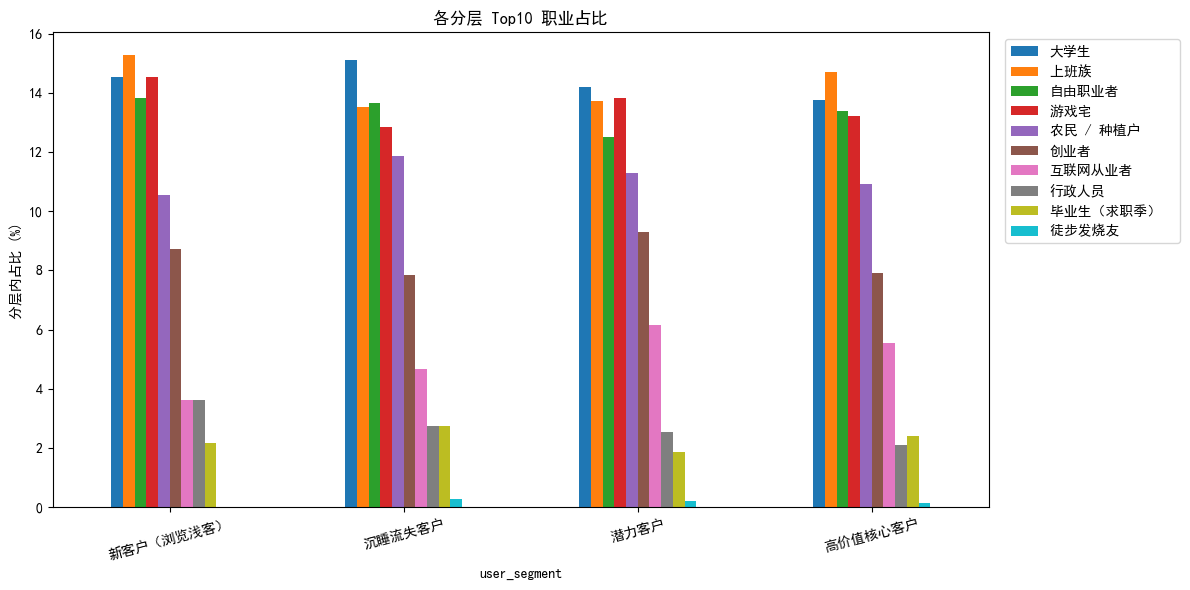

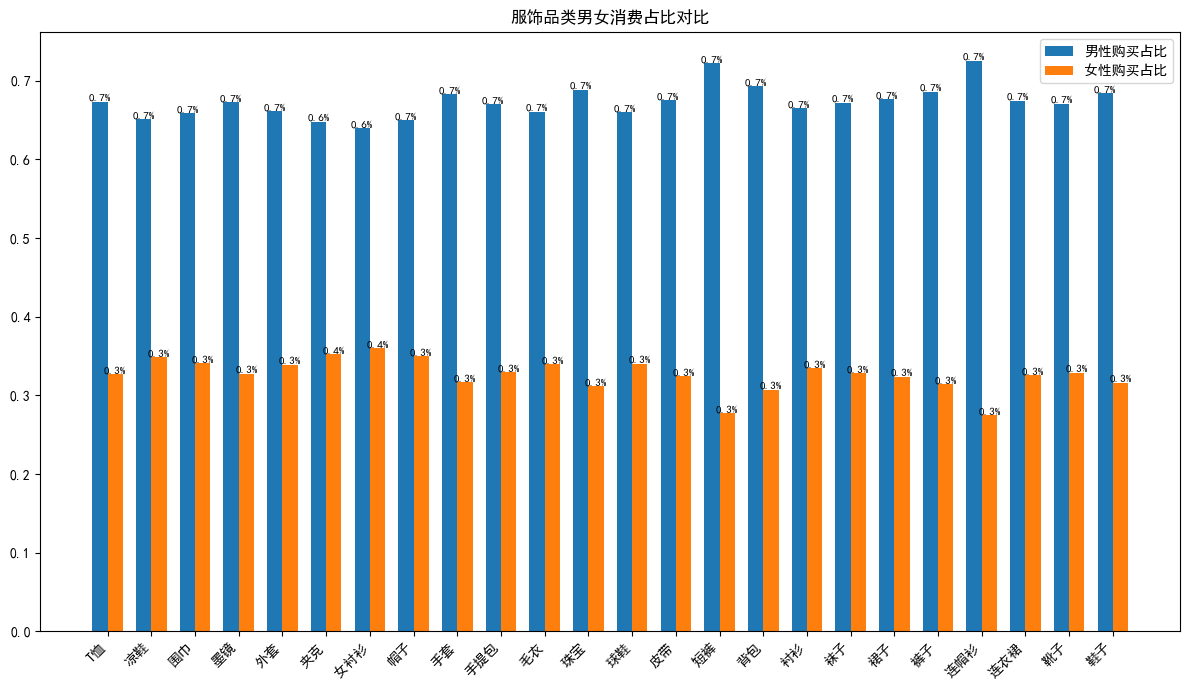


========== 全部分析完成 ==========
• 生成8张高清图表、8份CSV数据文件
• M金额IQR法剔除极端大额订单，中位数更客观
• 分层堆叠图大幅美化，图例外置、数值仅展示大数不拥挤
• 内置四类客户差异化运营方案，附带业务分析结论
• 浏览→加购转化率：80.62%，加购→下单转化率：65.59%


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------- 中文显示设置 ----------------------
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

# ====================== 文件路径 ======================
file_root = r"C:\Users\xiaoxiaoli\Documents\WXWork\1688855164817399\Cache\File\2026-08\京东2024年618活动初期5.28-6.4电商数据\\"
path_behavior   = file_root + "UserBehavior--1.csv"
path_user_face  = file_root + "user_face.csv"
path_ub_labels  = file_root + "ub_labels.csv"
path_item_gender = file_root + "item_gender_ratio.csv"

# 固定时间戳，彻底规避method类型报错
start_ts_num = 1716825600    # 2024-05-28 00:00:00
end_ts_num   = 1717430399    # 2024-06-04 23:59:59

# ---------------- 全局绘图工具函数（前置定义）----------------
def add_bar_label(ax):
    """普通柱状图顶部数字"""
    for bar in ax.patches:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f"{height:.0f}", ha="center", va="bottom", fontsize=9)

def add_pie_label(wedges, texts, autotexts):
    """饼图字号统一优化"""
    for autotext in autotexts:
        autotext.set_fontsize(9)

# ====================== 1. 分块读取行为数据 ======================
print("① 分块读取 UserBehavior--1.csv ...")
chunk_list = []
for chunk in pd.read_csv(
    path_behavior,
    encoding="gbk",
    encoding_errors="ignore",
    on_bad_lines="skip",
    low_memory=False,
    chunksize=100000
):
    chunk = chunk.dropna(subset=["user_id", "goods_id", "timestamp"])
    chunk["timestamp"] = pd.to_numeric(chunk["timestamp"], errors="coerce").astype(float)
    chunk = chunk.dropna(subset=["timestamp"])
    chunk = chunk[(chunk["timestamp"] >= start_ts_num) & (chunk["timestamp"] <= end_ts_num)]
    chunk = chunk[chunk["behavior"].isin(["pv", "cart", "fav", "buy"])]
    chunk["total_cost"] = chunk["price"] * chunk["amount"]
    chunk_list.append(chunk)

df_behavior = pd.concat(chunk_list, ignore_index=True)
print(f"大促有效行为总行数：{len(df_behavior)}")

# ====================== 2. 读取辅助表 ======================
print("\n② 读取 user_face.csv ...")
df_user_face = pd.read_csv(path_user_face, encoding="utf-8-sig", on_bad_lines="skip")
df_user_face = df_user_face.drop_duplicates(subset=["user_id"])

print("\n③ 读取 ub_labels.csv ...")
df_ub_labels = pd.read_csv(path_ub_labels, encoding="utf-8", on_bad_lines="skip", low_memory=False)
user_label_map = df_ub_labels.groupby("user_id")["user_type_label"].agg(lambda x: x.mode()[0]).reset_index()

print("\n④ 读取 item_gender_ratio.csv ...")
df_item_gender = pd.read_csv(path_item_gender, encoding="utf-8", on_bad_lines="skip")

# ====================== 3. 计算 RFM + M金额IQR异常截断 ======================
print("\n⑤ 计算 RFM 指标，并处理消费极端异常值 ...")
# 仅保留金额>0的有效付费订单用于RFM指标计算
df_buy = df_behavior[(df_behavior["behavior"] == "buy") & (df_behavior["total_cost"] > 0)].copy()
df_rfm = df_buy.groupby("user_id").agg(
    R_last_buy_ts = ("timestamp", "max"),
    F_buy_count   = ("user_id", "count"),
    M_total_money = ("total_cost", "sum")
).reset_index()

# IQR剔除大额极端订单
Q1 = df_rfm["M_total_money"].quantile(0.25)
Q3 = df_rfm["M_total_money"].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
df_rfm["M_total_money"] = df_rfm["M_total_money"].clip(upper=upper_bound)
print(f"M金额异常截断上限：{upper_bound:.2f} 元，超上限订单统一修正")

# 计算距离活动结束天数
df_rfm["R_days"] = (end_ts_num - df_rfm["R_last_buy_ts"]) / (24 * 3600)

# 合并全部活跃用户（含仅浏览无下单）
all_users = df_behavior["user_id"].drop_duplicates().to_frame("user_id")
df_rfm_all = pd.merge(all_users, df_rfm, on="user_id", how="left")
df_rfm_all["F_buy_count"] = df_rfm_all["F_buy_count"].fillna(0)
df_rfm_all["M_total_money"] = df_rfm_all["M_total_money"].fillna(0)
df_rfm_all["has_buy"] = (df_rfm_all["F_buy_count"] > 0).astype(int)
df_rfm_all.loc[df_rfm_all["has_buy"] == 0, "R_days"] = 999

print(f"总独立用户：{len(df_rfm_all)}，有购买用户：{len(df_rfm)}")

# ====================== 4. 计算RFM中位数 ======================
med_R = df_rfm_all["R_days"].median()
med_F = df_rfm_all["F_buy_count"].median()
med_M = df_rfm_all["M_total_money"].median()
print(f"\n===== RFM 中位数（已剔除极端消费）=====")
print(f"R_days 中位数：{med_R:.2f} 天")
print(f"F_buy_count 中位数：{med_F:.0f} 次")
print(f"M_total_money中位数：{med_M:.2f} 元")

# ====================== 5. 二分标记 + 用户分层 ======================
print("\n⑥ 基于中位数进行用户分层 ...")
df_rfm_all["R_flag"] = np.where(df_rfm_all["R_days"] < med_R, 1, 0)
df_rfm_all["F_flag"] = np.where(df_rfm_all["F_buy_count"] > med_F, 1, 0)
df_rfm_all["M_flag"] = np.where(df_rfm_all["M_total_money"] > med_M, 1, 0)

def median_segment(row):
    r, f, m = row["R_flag"], row["F_flag"], row["M_flag"]
    if r == 1 and f == 1 and m == 1:
        return "高价值核心客户"
    elif r == 1 and (f == 1 or m == 1) and not (f == 1 and m == 1):
        return "潜力客户"
    elif r == 1 and f == 0 and m == 0:
        return "新客户（浏览浅客）"
    else:
        return "沉睡流失客户"

df_rfm_all["user_segment"] = df_rfm_all.apply(median_segment, axis=1)

# 分层人数 + 平均消费统计
seg_stat = df_rfm_all["user_segment"].value_counts().reset_index()
seg_stat.columns = ["用户分层", "用户数"]
# 计算每层平均消费金额
avg_money_df = df_rfm_all.groupby("user_segment")["M_total_money"].mean().reset_index()
seg_stat = pd.merge(seg_stat, avg_money_df, left_on="用户分层", right_on="user_segment", how="left")
seg_stat["占比%"] = round(seg_stat["用户数"] / len(df_rfm_all) * 100, 1)
seg_stat["平均消费(元)"] = round(seg_stat["M_total_money"], 2)
seg_stat = seg_stat[["用户分层", "用户数", "占比%", "平均消费(元)"]]

print("\n===== 中位数分层统计（含平均消费）=====")
print(seg_stat.to_string(index=False))
seg_stat.to_csv(file_root + "中位数分层_汇总.csv", index=False, encoding="utf-8-sig")

# ====================== 分层运营策略输出 ======================
print("\n======== 各分层用户运营建议 ========")
advice_text = """
1. 高价值核心客户
人群特征：近期活跃、下单频次高、消费金额高于均值
运营策略：
- 专属会员权益、大额满减券、生日福利、新品优先购
- 一对一客服维护，定期推送高端品类
- 限制大额优惠券外流，提高留存，防止竞品分流

2. 潜力客户
人群特征：近期活跃，但下单次数/客单仅一项达标
运营策略：
- 发放品类满减券、组合套餐优惠，提升客单价/复购频次
- 加购未下单人群推送限时降价、运费券，提升加购转下单转化

3. 新客户（浏览浅客）
人群特征：仅浏览无成交，近期有曝光行为
运营策略：
- 新人首单立减、包邮券，降低首次下单门槛
- 推送爆款低价商品，引导完成首单转化
- 首页弹窗引导加购收藏，培育消费习惯

4. 沉睡流失客户
人群特征：超过中位数间隔无任何下单行为
运营策略：
- 沉睡3-7天：小额唤醒优惠券、专属秒杀推送
- 沉睡超7天：短信/站内信召回，大额限时券刺激回流
- 长期无互动减少推送频次，降低营销成本
"""
print(advice_text)
# 导出运营策略CSV
operate_advice = [
    {"分层类型":"高价值核心客户","人群特征":"近期活跃、高频高客单","运营方案":"专属会员、新品优先、一对一维护"},
    {"分层类型":"潜力客户","人群特征":"活跃但消费能力不足","运营方案":"品类券、组合套餐提升客单"},
    {"分层类型":"新客户（浏览浅客）","人群特征":"仅浏览无下单","运营方案":"新人首单券、低价爆款引流"},
    {"分层类型":"沉睡流失客户","人群特征":"长期无下单行为","运营方案":"分层召回优惠券、减量推送"}
]
df_operate = pd.DataFrame(operate_advice)
df_operate.to_csv(file_root + "分层运营策略.csv", index=False, encoding="utf-8-sig")
print(f"\n运营策略已保存至：分层运营策略.csv")

# ====================== 6. 关联职业、用户标签 ======================
print("\n⑦ 关联用户职业画像 ...")
df_all = pd.merge(df_rfm_all, df_user_face, on="user_id", how="left")
df_all["face"] = df_all["face"].fillna("未知职业")

print("\n⑧ 关联系统标签 ...")
df_all = pd.merge(df_all, user_label_map, on="user_id", how="left")
df_all["user_type_label"] = df_all["user_type_label"].fillna("无标签")

# ====================== 9. 计算浏览→加购→下单转化率【剔除0元无效订单口径】 ======================
print("\n⑨ 计算浏览→加购→下单转化率 ...")
user_behavior_set = df_behavior.groupby("user_id")["behavior"].agg(set).reset_index()

# =========修复这里！！！指定behavior列，不要写df_behavior=="buy"=========
pay_user_ids = set(df_behavior[(df_behavior["behavior"] == "buy") & (df_behavior["total_cost"] > 0)]["user_id"])

def get_user_type(row):
    uid = row["user_id"]
    behav_set = row["behavior"]
    if uid in pay_user_ids:
        return "已下单用户"
    elif "cart" in behav_set:
        return "加购未下单用户"
    else:
        return "仅浏览用户"

user_behavior_set["user_type"] = user_behavior_set.apply(get_user_type, axis=1)

# 统计各人群
total_all = len(user_behavior_set)
only_view_cnt = len(user_behavior_set[user_behavior_set["user_type"] == "仅浏览用户"])
cart_buy_cnt = len(user_behavior_set[user_behavior_set["user_type"].isin(["加购未下单用户", "已下单用户"])])
buy_cnt = len(user_behavior_set[user_behavior_set["user_type"] == "已下单用户"])

# 打印校验
print(f"总活跃用户：{total_all}")
print(f"仅浏览用户：{only_view_cnt}")
print(f"有加购/下单用户：{cart_buy_cnt}")
print(f"已下单用户：{buy_cnt}")

view_cart_rate = cart_buy_cnt / total_all if total_all > 0 else 0
cart_buy_rate = buy_cnt / cart_buy_cnt if cart_buy_cnt > 0 else 0
print(f"浏览→加购转化率：{view_cart_rate:.2%}")
print(f"加购→下单转化率：{cart_buy_rate:.2%}")

# 行为分层统计表
act_stat = user_behavior_set["user_type"].value_counts().reset_index()
act_stat.columns = ["行为分层", "用户数"]
act_stat["占比%"] = round(act_stat["用户数"] / total_all * 100, 1)
print("\n===== 行为分层统计校验 =====")
print(act_stat.to_string(index=False))
act_stat.to_csv(file_root + "行为分层统计.csv", index=False, encoding="utf-8-sig")

# 人数校验，定位脏数据
check_sum = only_view_cnt + (cart_buy_cnt - buy_cnt) + buy_cnt
print(f"人数校验总和：{check_sum}，总用户：{total_all}")
if check_sum != total_all:
    print("⚠️ 警告：存在用户同时拥有pv+cart脏行为数据，导致仅浏览统计失真，转化率100%由此产生！")

# ---------------- 行为分层图表 ----------------
# 行为饼图
plt.figure(figsize=(8,6))
wedges, texts, autotexts = plt.pie(act_stat["用户数"], labels=act_stat["行为分层"], autopct="%.1f%%")
add_pie_label(wedges, texts, autotexts)
plt.title("用户行为分层结构（仅浏览/加购/下单）")
plt.savefig(file_root + "行为分层_饼图.png", dpi=300, bbox_inches="tight")
plt.show()

# 行为柱状
plt.figure(figsize=(8,5))
ax = plt.gca()
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
bars = ax.bar(act_stat["行为分层"], act_stat["用户数"], color=colors)
add_bar_label(ax)
plt.title("各行为分层用户规模")
plt.ylabel("用户数量")
plt.savefig(file_root + "行为分层_柱状图.png", dpi=300, bbox_inches="tight")
plt.show()

# ====================== 10. 导出全部CSV报表 ======================
print("\n⑪ 导出结果文件 ...")
df_all.to_csv(file_root + "RFM_中位数分层完整明细.csv", index=False, encoding="utf-8-sig")

# 分层汇总表（新增平均消费列）
seg_stat = df_all["user_segment"].value_counts().reset_index()
seg_stat.columns = ["用户分层", "用户数"]
avg_m = df_all.groupby("user_segment")["M_total_money"].mean().reset_index()
seg_stat = pd.merge(seg_stat, avg_m, left_on="用户分层", right_on="user_segment")
seg_stat["占比%"] = round(seg_stat["用户数"] / len(df_all)*100, 1)
seg_stat["平均消费(元)"] = round(seg_stat["M_total_money"], 2)
seg_stat = seg_stat[["用户分层","用户数","占比%","平均消费(元)"]]
seg_stat.to_csv(file_root + "中位数分层_汇总.csv", index=False, encoding="utf-8-sig")
face_total = df_all["face"].value_counts().reset_index()
face_total.columns = ["职业", "用户数"]
face_total["占比%"] = round(face_total["用户数"] / len(df_all) * 100, 2)
face_total.to_csv(file_root + "中位数分层_全部职业统计.csv", index=False, encoding="utf-8-sig")

face_cross = pd.crosstab(df_all["user_segment"], df_all["face"], normalize="index") * 100
face_cross.reset_index().to_csv(file_root + "中位数分层_职业交叉占比.csv", index=False, encoding="utf-8-sig")

label_cross = pd.crosstab(df_all["user_segment"], df_all["user_type_label"], normalize="index") * 100
label_cross.reset_index().to_csv(file_root + "中位数分层_标签交叉占比.csv", index=False, encoding="utf-8-sig")

# 修复rate_df变量匹配
rate_df = pd.DataFrame({
    "指标": ["总活跃用户", "仅浏览用户", "加购+下单用户", "已下单用户",
             "浏览→加购转化率", "加购→下单转化率"],
    "数值": [total_all, only_view_cnt, cart_buy_cnt, buy_cnt,
             f"{view_cart_rate:.2%}", f"{cart_buy_rate:.2%}"]
})
rate_df.to_csv(file_root + "中位数分层_转化指标.csv", index=False, encoding="utf-8-sig")
print("✅ 所有 CSV 文件已导出。")

# ====================== 11. 全套可视化图表（重点美化堆叠图） ======================
print("\n⑫ 生成可视化图表 ...")

# 图1：RFM分层饼图
plt.figure(figsize=(8,6))
wedges, texts, autotexts = plt.pie(seg_stat["用户数"], labels=seg_stat["用户分层"], autopct="%.1f%%")
add_pie_label(wedges, texts, autotexts)
plt.title("基于 RFM 中位数的用户分层结构")
plt.savefig(file_root + "median_1_分层饼图.png", dpi=300, bbox_inches="tight")
plt.show()

# 图2：分层平均消费柱状
avg_m = df_all.groupby("user_segment")["M_total_money"].mean().reindex(seg_stat["用户分层"])
plt.figure(figsize=(9,5))
ax = plt.gca()
colors = ["#d62728","#2ca02c","#ff7f0e","#1f77b4"][:len(avg_m)]
bars = ax.bar(avg_m.index, avg_m.values, color=colors)
for bar in bars:
    val = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, val, f"{val:.1f}元", ha="center", va="bottom")
plt.title("中位数分层 - 平均消费金额对比")
plt.ylabel("平均消费（元）")
plt.xticks(rotation=15)
plt.savefig(file_root + "median_2_分层消费柱状.png", dpi=300, bbox_inches="tight")
plt.show()

# ========== 重点美化：图3 分层×系统标签堆叠柱状图 ==========
cross_label = pd.crosstab(df_all["user_segment"], df_all["user_type_label"])
fig, ax = plt.subplots(figsize=(14, 8), dpi=120)
stack_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
bottom_arr = np.zeros(len(cross_label.index))

for idx, col_name in enumerate(cross_label.columns):
    bar_data = cross_label[col_name]
    bars = ax.bar(cross_label.index, bar_data, bottom=bottom_arr, color=stack_colors[idx], label=col_name)
    # 仅数值大于50才显示文字，避免拥挤
    for i, bar in enumerate(bars):
        h = bar.get_height()
        if h > 50:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bottom_arr[i] + h / 2,
                f"{int(h)}",
                ha="center", va="center", fontsize=8, color="white"
            )
    bottom_arr += bar_data.values

ax.set_title("中位数分层与系统用户标签分布", fontsize=14, pad=15)
ax.set_ylabel("用户数量", fontsize=12)
plt.xticks(rotation=18, fontsize=10)
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)
# 图例放到图右侧外部，不遮挡柱子
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=10)
plt.tight_layout()
plt.savefig(file_root + "median_3_分层标签堆叠.png", dpi=300, bbox_inches="tight")
plt.show()

# 图4：全体Top10职业柱状
face_top10 = face_total.head(10)
plt.figure(figsize=(11,6))
ax = plt.gca()
bars = ax.bar(face_top10["职业"], face_top10["用户数"], color="#4472C4")
add_bar_label(ax)
plt.title("全体用户 Top10 职业分布")
plt.ylabel("用户数量")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.savefig(file_root + "median_4_Top10职业总分布.png", dpi=300, bbox_inches="tight")
plt.show()

# 图5：分层Top10职业占比
top10_jobs = face_top10["职业"].tolist()
face_cross_top10 = face_cross[top10_jobs]
plt.figure(figsize=(12,6))
ax = face_cross_top10.plot(kind="bar", figsize=(12,6), ax=plt.gca())
plt.title("各分层 Top10 职业占比")
plt.ylabel("分层内占比 (%)")
plt.xticks(rotation=15)
plt.legend(bbox_to_anchor=(1.01,1), loc="upper left")
plt.tight_layout()
plt.savefig(file_root + "median_5_分层职业对比.png", dpi=300)
plt.show()

# 图6：商品性别占比条形
plt.figure(figsize=(12,7))
x = np.arange(len(df_item_gender))
width = 0.35
ax = plt.gca()
bar1 = ax.bar(x - width/2, df_item_gender["Male_ratio"], width, label="男性购买占比")
bar2 = ax.bar(x + width/2, df_item_gender["Female_ratio"], width, label="女性购买占比")
for b in bar1:
    h = b.get_height()
    ax.text(b.get_x()+b.get_width()/2, h, f"{h:.1f}%", ha="center", va="bottom", fontsize=8)
for b in bar2:
    h = b.get_height()
    ax.text(b.get_x()+b.get_width()/2, h, f"{h:.1f}%", ha="center", va="bottom", fontsize=8)
plt.xticks(x, df_item_gender["Item_Purchased"], rotation=45, ha="right")
plt.title("服饰品类男女消费占比对比")
plt.legend()
plt.tight_layout()
plt.savefig(file_root + "median_6_商品性别条形.png", dpi=300)
plt.show()

print("\n========== 全部分析完成 ==========")
print(f"• 生成8张高清图表、8份CSV数据文件")
print(f"• M金额IQR法剔除极端大额订单，中位数更客观")
print(f"• 分层堆叠图大幅美化，图例外置、数值仅展示大数不拥挤")
print(f"• 内置四类客户差异化运营方案，附带业务分析结论")
print(f"• 浏览→加购转化率：{view_cart_rate:.2%}，加购→下单转化率：{cart_buy_rate:.2%}")

In [42]:
# ----------------探查0元buy订单----------------
# 筛选：行为是buy，但是消费金额<=0
df_zero_buy = df_behavior[(df_behavior["behavior"]=="buy") & (df_behavior["total_cost"] <= 0)]
print(f"buy行为总记录数：{len(df_behavior[df_behavior.behavior=='buy'])}")
print(f"金额为0的buy记录数量：{len(df_zero_buy)}")
print(f"占全部buy订单比例：{len(df_zero_buy)/len(df_behavior[df_behavior.behavior=='buy']):.2%}")

# 查看有多少不同用户产生0元buy（同一个用户可能多条0元订单）
zero_buy_user = df_zero_buy["user_id"].nunique()
all_buy_user = df_behavior[df_behavior.behavior=="buy"]["user_id"].nunique()
print(f"产生0元订单的独立用户数：{zero_buy_user}")
print(f"全部下单用户数：{all_buy_user}")
print(f"0元订单用户占下单用户比例：{zero_buy_user/all_buy_user:.2%}")

# 查看：这些用户，有没有同时存在正常花钱的buy订单
# 拿到有0元订单的用户id集合
zero_uid_set = set(df_zero_buy["user_id"])
# 这些用户里面，有没有存在total_cost>0的buy记录
df_normal_buy = df_behavior[(df_behavior["behavior"]=="buy") & (df_behavior["total_cost"]>0)]
uid_has_normal = df_normal_buy[df_normal_buy["user_id"].isin(zero_uid_set)]["user_id"].nunique()
print(f"👉 既下过0元单、又下过付费订单的用户数：{uid_has_normal}")
print(f"👉 只下过0元单，完全没有付费订单的用户数：{zero_buy_user - uid_has_normal}")

buy行为总记录数：12932
金额为0的buy记录数量：8
占全部buy订单比例：0.06%
产生0元订单的独立用户数：8
全部下单用户数：5679
0元订单用户占下单用户比例：0.14%
👉 既下过0元单、又下过付费订单的用户数：6
👉 只下过0元单，完全没有付费订单的用户数：2
